In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, ifftshift
from skimage import data
from skimage.transform import resize

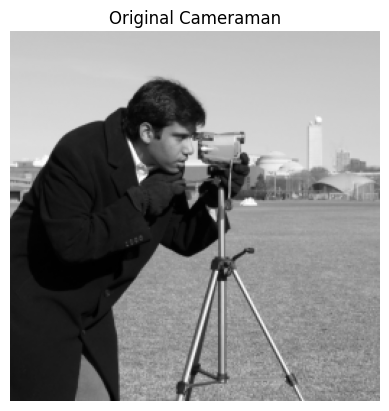

In [2]:
os.makedirs("Lab6_outputs", exist_ok=True)

image = data.camera()
image = resize(image, (256, 256), anti_aliasing=True)
M, N = image.shape

plt.imshow(image, cmap='gray')
plt.title("Original Cameraman")
plt.axis('off')
plt.show()

In [4]:
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)
F = fft2(image)
F_lap = F * laplacian_filter
laplacian_image = ifft2(F_lap).real

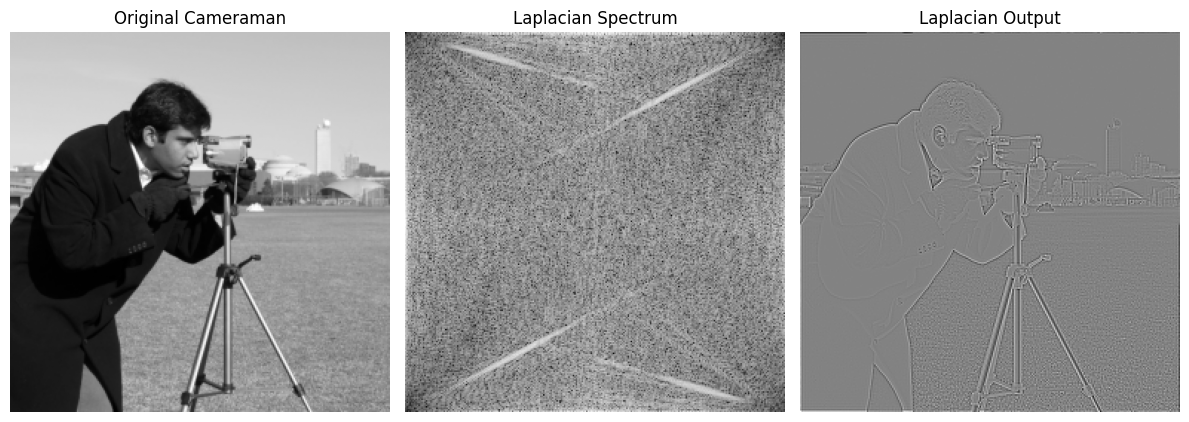

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian Output')
plt.axis('off')

plt.tight_layout()
plt.savefig("Lab6_outputs/task1_laplacian_results.png", dpi=300)
plt.show()

In [6]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    return fft2(ifftshift(padded))

In [8]:
F = fft2(image)

H_sobel_x = center_embed_kernel(sobel_x, image.shape)
H_sobel_y = center_embed_kernel(sobel_y, image.shape)

F_sobel_x = F * H_sobel_x
F_sobel_y = F * H_sobel_y

sobel_x_image = ifft2(F_sobel_x).real
sobel_y_image = ifft2(F_sobel_y).real
sobel_magnitude = np.sqrt(sobel_x_image**2 + sobel_y_image**2)

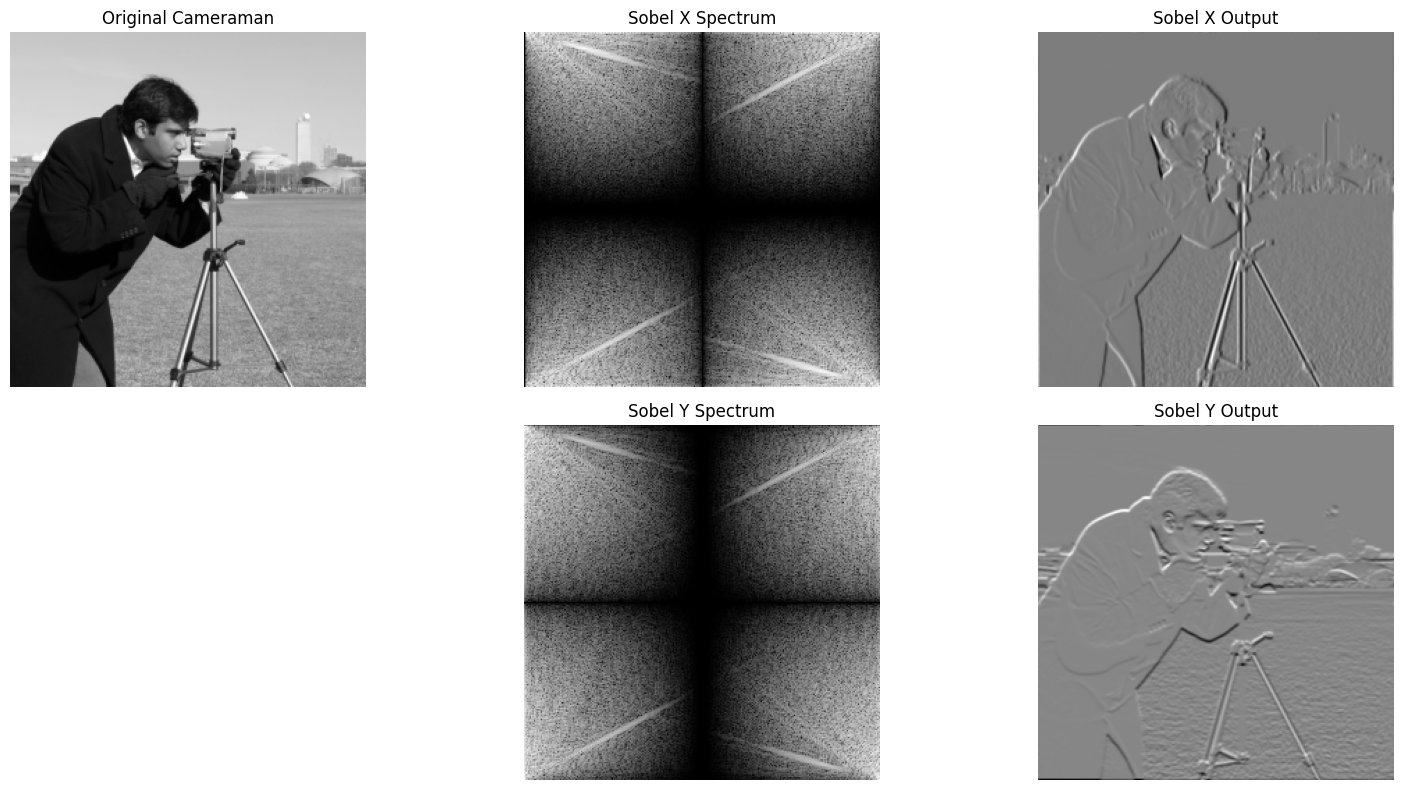

In [9]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(F_sobel_x)), cmap='gray')
plt.title('Sobel X Spectrum')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X Output')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.log(1 + np.abs(F_sobel_y)), cmap='gray')
plt.title('Sobel Y Spectrum')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y Output')
plt.axis('off')

plt.tight_layout()
plt.savefig("Lab6_outputs/assessment_sobel_xy_results.png", dpi=300)
plt.show()

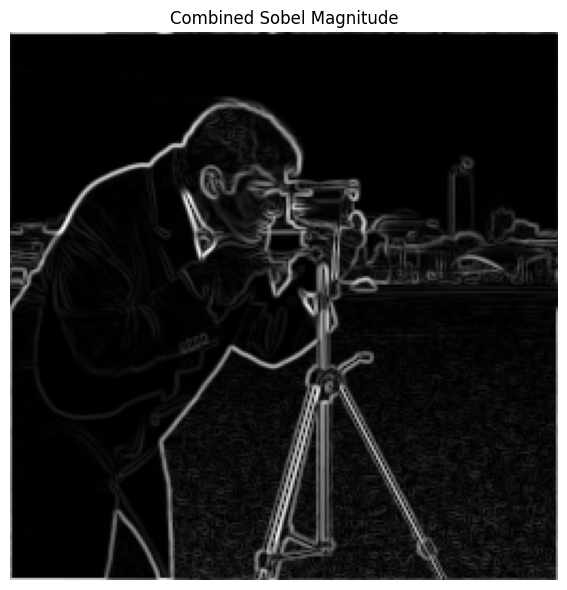

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Combined Sobel Magnitude')
plt.axis('off')
plt.tight_layout()
plt.savefig("Lab6_outputs/assessment_sobel_magnitude.png", dpi=300)
plt.show()

In [11]:
plt.imsave("Lab6_outputs/task1_laplacian_output.png", laplacian_image, cmap='gray')
plt.imsave("Lab6_outputs/sobel_x_output.png", sobel_x_image, cmap='gray')
plt.imsave("Lab6_outputs/sobel_y_output.png", sobel_y_image, cmap='gray')
plt.imsave("Lab6_outputs/sobel_magnitude_output.png", sobel_magnitude, cmap='gray')

print("All outputs saved successfully.")

All outputs saved successfully.
